# 🏔️ บทที่ 05 — Cross-section & RHI: โครงสร้างแนวดิ่งของพายุ (ฉบับขยาย)
### หลักสูตรแลปเรดาร์ตรวจอากาศด้วย Py-ART และ wradlib

**ระดับ:** ขั้นกลาง  |  **ต้องมีก่อน:** รันบทที่ 00 แล้ว (ต่อยอดกริด 3 มิติจากบท 04)

การดูฝนจากด้านบน (PPI/CAPPI) บอกการกระจายเชิงพื้นที่ แต่การเข้าใจ **ความรุนแรง/ชนิดของพายุ** ต้องดู **โครงสร้างแนวดิ่ง** ผ่าน **RHI** และ **cross-section** บทนี้ให้นิสิตเจาะลึกแนวดิ่งผ่าน 10 ตัวอย่างต่อเนื่อง

**เส้นเรื่องของบท (ร้อยเรียง):**
| # | หัวข้อ |
|---|---|
| A1 | Pseudo-RHI จากปริมาตร PPI (ตามทิศ azimuth) |
| A2 | สร้างกริด 3 มิติ (ฐานของ cross-section) |
| A3 | Cross-section แนว E–W และ N–S ผ่านแกนพายุ |
| A4 | Cross-section ตามเส้นใด ๆ (interpolate) |
| A5 | เทียบแกนพาความร้อน vs ฝนสตราติฟอร์ม |
| A6 | Echo top: ความสูงยอดฝนเชิงพื้นที่ |
| A7 | ความสูงของ dBZ ที่กำหนด (เช่น 30 dBZ) |
| A8 | โปรไฟล์แนวดิ่งเฉลี่ย (VPR) |
| A9 | พัดของ cross-section หลายทิศ (fan) |
| A10 | ดัชนีความรุนแรงแนวดิ่ง (คล้าย VIL) |

---


## 🧠 หลักการเบื้องต้น

- **RHI (Range-Height Indicator)** = การกวาดแนวดิ่งที่ **azimuth คงที่** (เปลี่ยนมุมยก) ได้ภาพ ระยะ–ความสูง โดยตรง แต่เรดาร์ตรวจอากาศส่วนใหญ่ (รวมพิษณุโลก) กวาดแบบ **PPI volume** จึงต้องสร้าง **pseudo-RHI** โดยตัดปริมาตร PPI ที่ทิศหนึ่ง
- **Cross-section** = การตัดกริด 3 มิติ (คาร์ทีเซียน) ตามเส้นใด ๆ เพื่อดูภาพแนวดิ่ง
- โครงสร้างแนวดิ่งบอกชนิดพายุ: **พาความร้อน (convective)** = แกนแคบ สูงชัน dBZ สูง; **สตราติฟอร์ม (stratiform)** = แผ่กว้าง เตี้ย อาจมี *bright band* ที่ระดับหลอมละลาย
- **Echo top** = ความสูงสูงสุดที่ยังมี echo เกินเกณฑ์ (เช่น 18 dBZ) บ่งชี้ความสูงของพายุ


## ⚙️ ส่วนหัวมาตรฐาน (ติดตั้งไลบรารี + เชื่อม Drive + ฟอนต์ไทย)


In [ ]:
%pip install -q arm_pyart scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.4/14.4 MB 77.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 96.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 66.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 90.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 307.5/307.5 kB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.6/206.6 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.8/157.8 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 55.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.3/47.3 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.4/15.4 MB 72.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the 

In [ ]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
import pyart
import warnings; warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')
ROOT = '/content/drive/MyDrive/tmd_radar_course'
sys.path.append(os.path.join(ROOT, '9config'))
import course_paths as P
assert os.path.exists(P.RADAR_1000), "⚠️ ไม่พบข้อมูลเรดาร์ — กรุณารัน Notebook 00 ก่อน"
OUT = P.results_dir('lesson05')
print("พร้อมแล้ว ✅  ผลลัพธ์บันทึกที่:", OUT)


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly supported
## by the U.S. Department of Energy Office of Science as part of
## the Atmospheric Radiation Measurement (ARM) User Facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119

Mounted at /content/drive
พร้อมแล้ว ✅  ผลลัพธ์บันทึกที่: /content/drive/MyDrive/tmd_radar_course/1results/lesson05


### 🔤 ติดตั้งฟอนต์ไทยสำหรับกราฟ (จำเป็น — มิฉะนั้นข้อความไทยจะแสดงเป็นกล่อง □□□)

ดาวน์โหลดฟอนต์ **Sarabun** (ฟอนต์ราชการไทย เหมาะงานตีพิมพ์) มาลงทะเบียนกับ matplotlib พร้อมตั้งสไตล์กราฟระดับตีพิมพ์ — รันเซลล์นี้ก่อนพลอตทุกครั้ง

In [ ]:
# ── ติดตั้ง & ตั้งค่าฟอนต์ไทยให้ matplotlib (ต้องรันก่อนพลอตกราฟที่มีข้อความไทย) ──
import os, glob, subprocess, urllib.request
import matplotlib as mpl, matplotlib.pyplot as plt, matplotlib.font_manager as fm

def setup_thai_font(verbose=True):
    d = '/usr/share/fonts/truetype/sarabun'; os.makedirs(d, exist_ok=True)
    # 1) Sarabun จาก Google Fonts (ฟอนต์ราชการไทย)
    if not glob.glob(d + '/*.ttf'):
        base = 'https://github.com/google/fonts/raw/main/ofl/sarabun/'
        for fn in ('Sarabun-Regular.ttf', 'Sarabun-Bold.ttf'):
            try: urllib.request.urlretrieve(base + fn, os.path.join(d, fn))
            except Exception: pass
    # 2) สำรอง: ฟอนต์ไทย TLWG ผ่าน apt (มีใน Colab เสมอ)
    if not glob.glob(d + '/*.ttf') and not glob.glob('/usr/share/fonts/truetype/tlwg/*.ttf'):
        subprocess.run(['apt-get', '-qq', '-y', 'install', 'fonts-thai-tlwg'], capture_output=True)
    # ลงทะเบียนฟอนต์ที่ติดตั้ง
    for fp in glob.glob(d + '/*.ttf') + glob.glob('/usr/share/fonts/truetype/tlwg/*.ttf'):
        try: fm.fontManager.addfont(fp)
        except Exception: pass
    avail = {f.name for f in fm.fontManager.ttflist}
    chosen = next((n for n in ('Sarabun','Loma','Garuda','Norasi') if n in avail), None)
    if chosen: mpl.rcParams['font.family'] = chosen
    mpl.rcParams['axes.unicode_minus'] = False
    if verbose:
        print('ฟอนต์ไทยที่ใช้:', chosen or 'ไม่พบ — ลองรันเซลล์นี้อีกครั้งหลังติดตั้ง')
    return chosen

setup_thai_font()
# สไตล์กราฟระดับตีพิมพ์ (ฟอนต์ใหญ่ อ่านง่าย)
plt.rcParams.update({'figure.dpi':120, 'savefig.dpi':300, 'font.size':13,
    'axes.titlesize':16, 'axes.labelsize':14, 'xtick.labelsize':12,
    'ytick.labelsize':12, 'legend.fontsize':13, 'axes.unicode_minus':False})

ฟอนต์ไทยที่ใช้: Sarabun


In [ ]:
radar = pyart.io.read(P.RADAR_1000)
gf = pyart.filters.GateFilter(radar)
gf.exclude_below('cross_correlation_ratio', 0.80)
gf.exclude_below('reflectivity', 0.0)
print("มุมยกที่มี:", np.round(radar.fixed_angle['data'],2), "°")

มุมยกที่มี: [0.48 1.48 2.39 3.39] °


---
## A1 — Pseudo-RHI จากปริมาตร PPI (ตามทิศ azimuth)

`pyart.util.cross_section_ppi` สร้างวัตถุคล้าย RHI โดยตัดทุกมุมยกที่ทิศ azimuth ที่เลือก


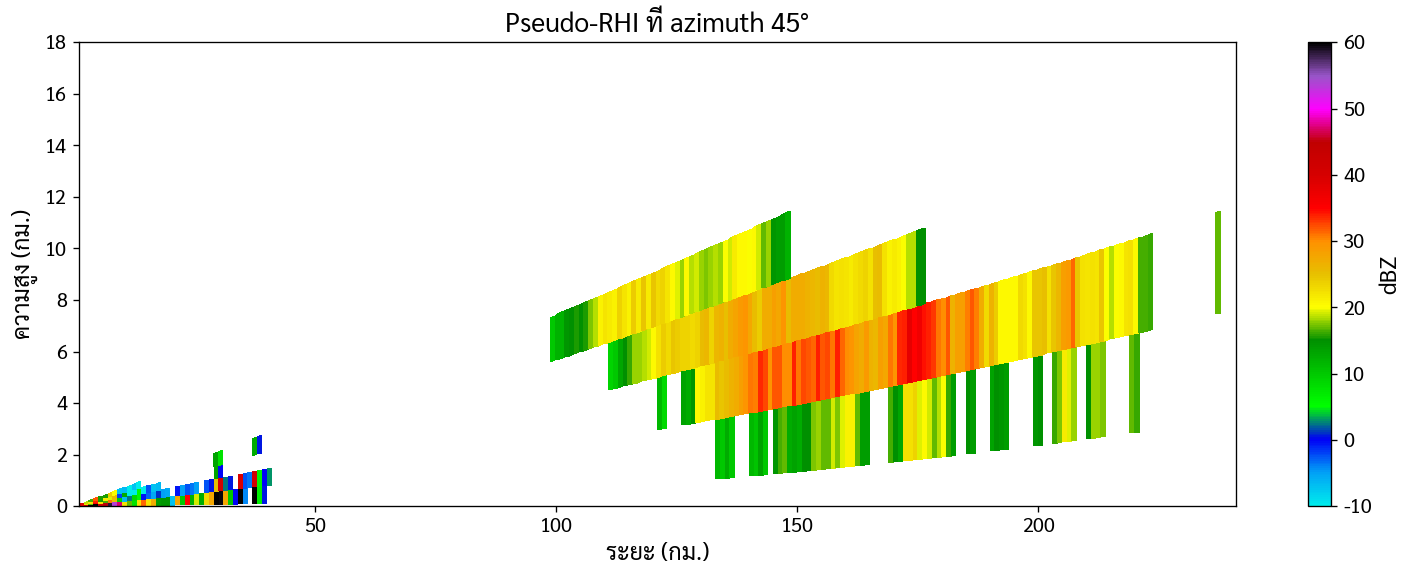

In [ ]:
TARGET_AZ = 45.0     # ทิศที่จะตัด (ปรับได้)
try:
    rhi = pyart.util.cross_section_ppi(radar, [TARGET_AZ], az_tol=2.0)
    fig, ax = plt.subplots(figsize=(13, 5))
    d = pyart.graph.RadarDisplay(rhi)
    d.plot('reflectivity', 0, ax=ax, vmin=-10, vmax=60, cmap='NWSRef', colorbar_label='dBZ',
           title=f'Pseudo-RHI ที่ azimuth {TARGET_AZ:.0f}°')
    ax.set_ylim(0, 18); ax.set_xlabel('ระยะ (กม.)'); ax.set_ylabel('ความสูง (กม.)')
    plt.tight_layout(); fig.savefig(os.path.join(OUT,'A1_pseudo_rhi.png'), dpi=200, bbox_inches='tight'); plt.show()
except Exception as e:
    print("cross_section_ppi มีปัญหา (เวอร์ชัน pyart):", repr(e))
    print("→ ใช้ cross-section จากกริด 3 มิติในหัวข้อถัดไปแทนได้")

**การแปลผล:** เห็นความสูงของฝนตามระยะในทิศที่เลือก แกนที่ dBZ สูงพุ่งขึ้นสูง = พาความร้อนแรง


## A2 — สร้างกริด 3 มิติ (ฐานของ cross-section)


In [ ]:
HALF = 240000.0; NZ = 21
grid = pyart.map.grid_from_radars((radar,), gatefilters=(gf,),
    grid_shape=(NZ, 241, 241),
    grid_limits=((0., 20000.), (-HALF, HALF), (-HALF, HALF)),
    fields=['reflectivity'], weighting_function='Barnes2')
vol = np.ma.filled(grid.fields['reflectivity']['data'], np.nan)   # (nz, ny, nx)
zkm = np.linspace(0, 20, NZ); xkm = np.linspace(-240, 240, 241); ykm = np.linspace(-240, 240, 241)

# หาแกนพายุจาก composite
colmax = np.nanmax(vol, axis=0)
iy, ix = np.unravel_index(np.nanargmax(colmax), colmax.shape)
print(f"แกนพายุ (composite สูงสุด): x={xkm[ix]:.0f} กม., y={ykm[iy]:.0f} กม., ค่า {colmax[iy,ix]:.0f} dBZ")

แกนพายุ (composite สูงสุด): x=22 กม., y=20 กม., ค่า 71 dBZ


## A3 — Cross-section แนว E–W และ N–S ผ่านแกนพายุ


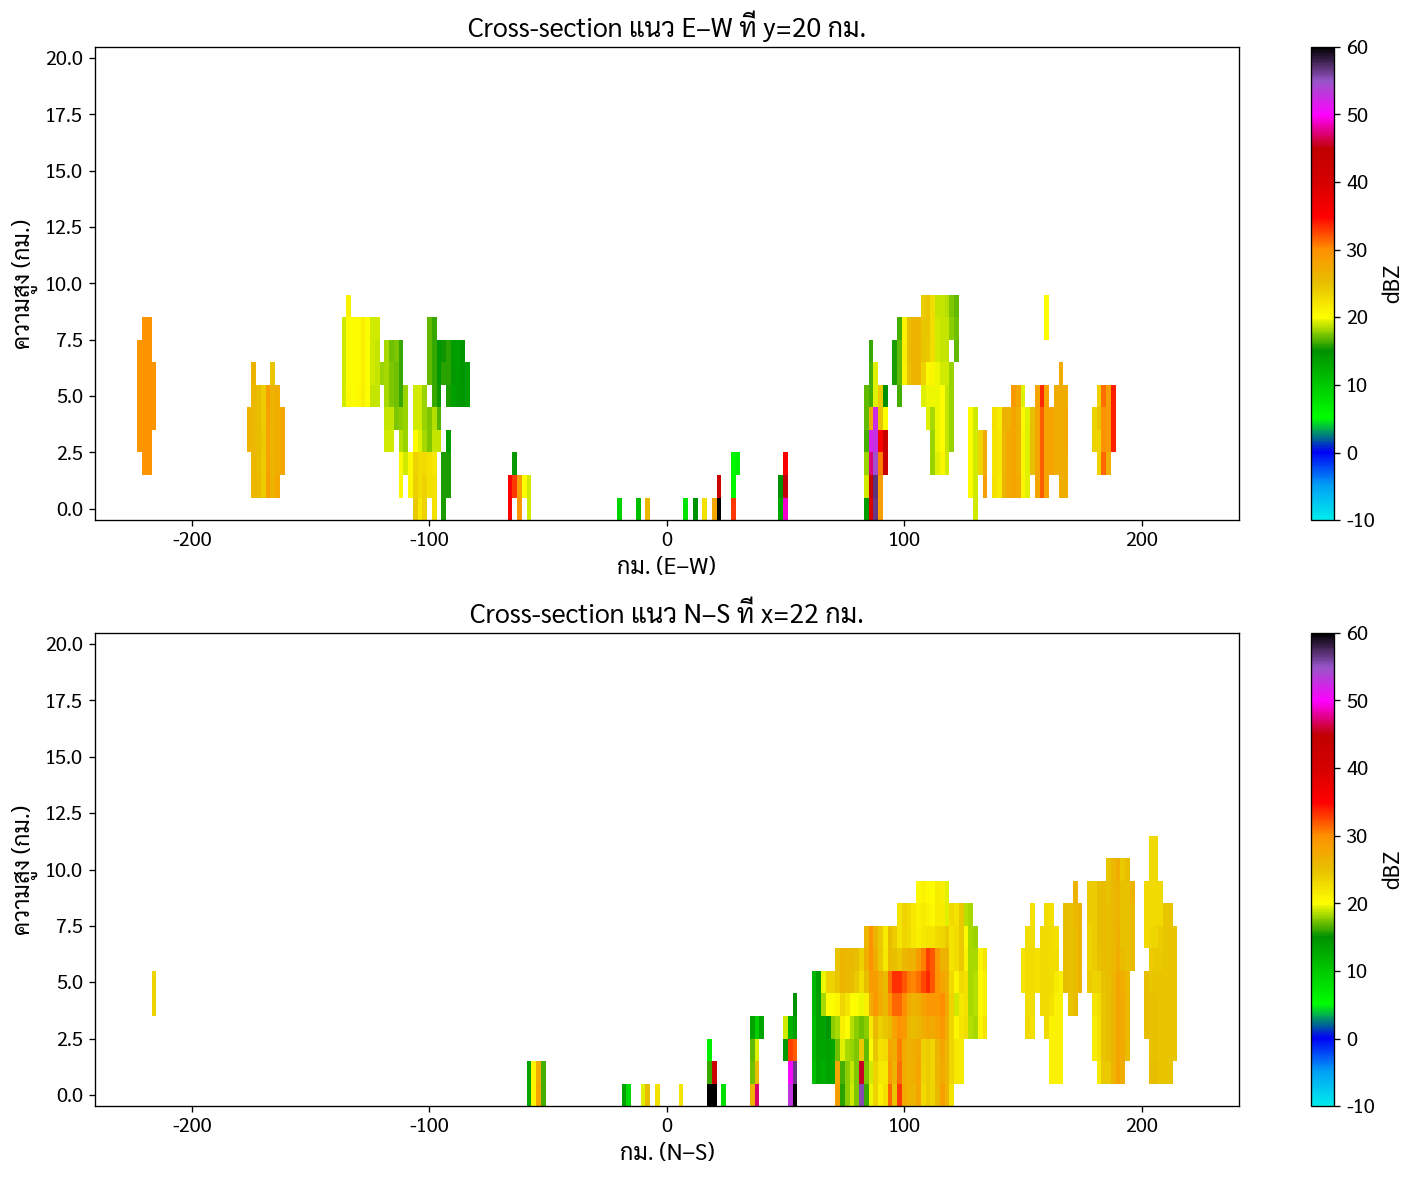

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(13, 10))
pm0 = axes[0].pcolormesh(xkm, zkm, np.ma.masked_invalid(vol[:, iy, :]), cmap='NWSRef',
                         vmin=-10, vmax=60, shading='auto')
axes[0].set_title(f'Cross-section แนว E–W ที่ y={ykm[iy]:.0f} กม.')
axes[0].set_xlabel('กม. (E–W)'); axes[0].set_ylabel('ความสูง (กม.)')
plt.colorbar(pm0, ax=axes[0], label='dBZ')

pm1 = axes[1].pcolormesh(ykm, zkm, np.ma.masked_invalid(vol[:, :, ix]), cmap='NWSRef',
                         vmin=-10, vmax=60, shading='auto')
axes[1].set_title(f'Cross-section แนว N–S ที่ x={xkm[ix]:.0f} กม.')
axes[1].set_xlabel('กม. (N–S)'); axes[1].set_ylabel('ความสูง (กม.)')
plt.colorbar(pm1, ax=axes[1], label='dBZ')
plt.tight_layout()
fig.savefig(os.path.join(OUT, 'A3_cross_EW_NS.png'), dpi=200, bbox_inches='tight')
plt.show()

**การแปลผล:** เห็นแกนฝนหนักยกตัวในแนวดิ่งทั้งสองแนว — ความชัน/ความสูงของแกนบ่งบอกความรุนแรงของพาความร้อน


## A4 — Cross-section ตามเส้นใด ๆ (interpolate)

ลากเส้นระหว่างสองจุด แล้วสุ่มค่ากริดตามเส้น (ด้วย `map_coordinates`) เพื่อได้ภาพตัดตามทิศที่สนใจ


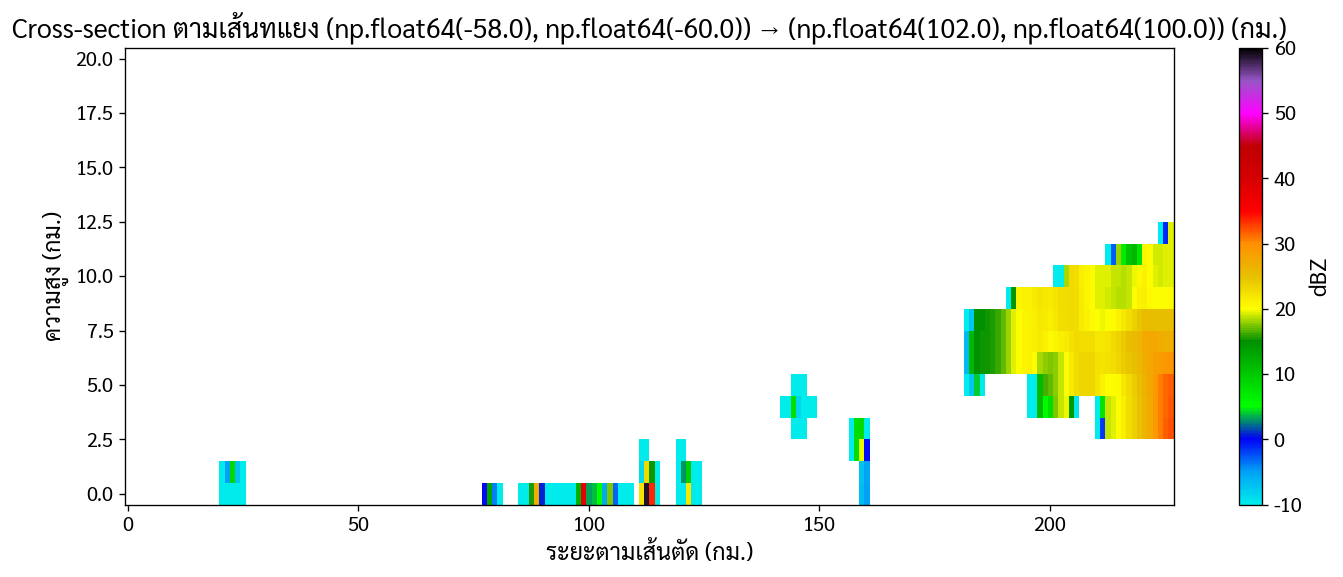

In [ ]:
from scipy.ndimage import map_coordinates

def cross_line(vol, p0, p1, npts=200):
    "ภาพตัดแนวดิ่งตามเส้นจาก p0=(x0,y0) ถึง p1=(x1,y1) หน่วยกิโลเมตร"
    xs = np.linspace(p0[0], p1[0], npts); ys = np.linspace(p0[1], p1[1], npts)
    ci = (xs + 240) / 480 * (vol.shape[2]-1)      # index x
    ri = (ys + 240) / 480 * (vol.shape[1]-1)      # index y
    out = np.full((vol.shape[0], npts), np.nan)
    for k in range(vol.shape[0]):
        layer = np.nan_to_num(vol[k], nan=-32.0)
        out[k] = map_coordinates(layer, [ri, ci], order=1, mode='constant', cval=np.nan)
    dist = np.hypot(xs - xs[0], ys - ys[0])
    return np.where(out < -31, np.nan, out), dist

p0 = (xkm[ix]-80, ykm[iy]-80); p1 = (xkm[ix]+80, ykm[iy]+80)   # เส้นทแยงผ่านแกนพายุ
sec, dist = cross_line(vol, p0, p1)

fig, ax = plt.subplots(figsize=(12, 5))
pm = ax.pcolormesh(dist, zkm, np.ma.masked_invalid(sec), cmap='NWSRef', vmin=-10, vmax=60, shading='auto')
ax.set_xlabel('ระยะตามเส้นตัด (กม.)'); ax.set_ylabel('ความสูง (กม.)')
ax.set_title(f'Cross-section ตามเส้นทแยง {p0} → {p1} (กม.)')
plt.colorbar(pm, ax=ax, label='dBZ')
plt.tight_layout()
fig.savefig(os.path.join(OUT, 'A4_cross_arbitrary.png'), dpi=200, bbox_inches='tight')
plt.show()

**การแปลผล:** ตัดตามเส้นใด ๆ ได้ ทำให้เลือกแนวที่ผ่าน "หัวใจ" ของพายุเพื่อดูโครงสร้างที่ต้องการ


## A5 — เทียบแกนพาความร้อน vs ฝนสตราติฟอร์ม

หาจุดที่ composite ต่ำ–ปานกลาง (สตราติฟอร์ม) เทียบกับแกนพาความร้อน แล้วดูโปรไฟล์แนวดิ่ง


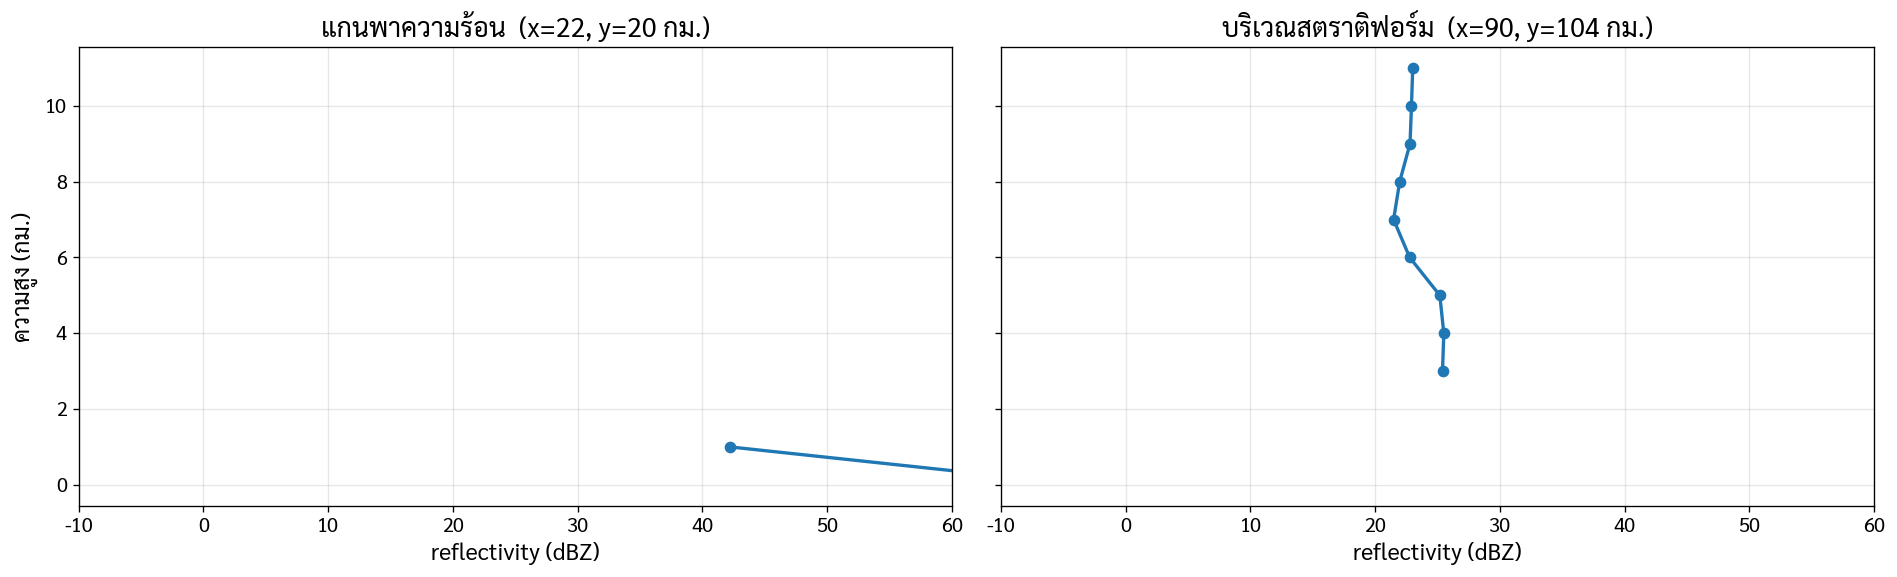

In [ ]:
# จุดพาความร้อน = แกนพายุ (ix,iy) ; จุดสตราติฟอร์ม = บริเวณ composite 20-30 dBZ ที่มีข้อมูล
strat_mask = (colmax > 20) & (colmax < 30)
if strat_mask.any():
    sy, sx = np.argwhere(strat_mask)[len(np.argwhere(strat_mask))//2]
else:
    sy, sx = iy, max(0, ix-60)

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
for ax, (yy, xx), t in zip(axes, [(iy, ix), (sy, sx)], ['แกนพาความร้อน', 'บริเวณสตราติฟอร์ม']):
    prof = vol[:, yy, xx]
    ax.plot(prof, zkm, marker='o', lw=2)
    ax.set_title(f'{t}  (x={xkm[xx]:.0f}, y={ykm[yy]:.0f} กม.)')
    ax.set_xlabel('reflectivity (dBZ)'); ax.set_xlim(-10, 60); ax.grid(alpha=0.3)
axes[0].set_ylabel('ความสูง (กม.)')
plt.tight_layout()
fig.savefig(os.path.join(OUT, 'A5_convective_vs_stratiform.png'), dpi=200, bbox_inches='tight')
plt.show()

**การแปลผล:** พาความร้อน = dBZ สูงต่อเนื่องขึ้นสูง; สตราติฟอร์ม = dBZ ปานกลาง เตี้ย อาจมีจุดเด่นที่ระดับหลอมละลาย (bright band ~4–5 กม.)


## A6 — Echo Top: ความสูงยอดฝนเชิงพื้นที่

ความสูงสูงสุดที่ยังมี dBZ เกินเกณฑ์ (เช่น 18 dBZ) — พายุยิ่งสูงยิ่งรุนแรง


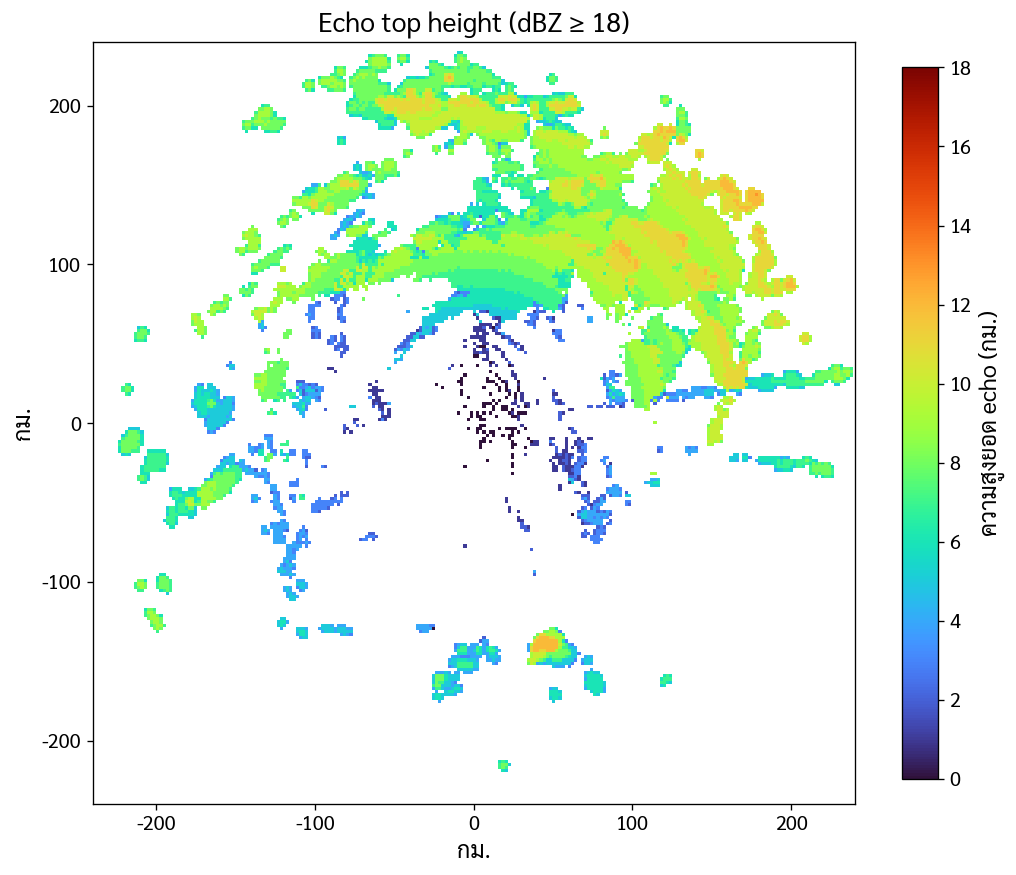

Echo top สูงสุดในพื้นที่ ≈ 13.0 กม.


In [ ]:
THRESH = 18.0
above = vol >= THRESH                       # (nz,ny,nx)
zg = zkm[:, None, None] * np.ones_like(vol)
echo_top = np.where(above, zg, np.nan)
echo_top = np.nanmax(echo_top, axis=0)      # (ny,nx)

fig, ax = plt.subplots(figsize=(9, 8))
pm = ax.imshow(echo_top, origin='lower', extent=[-240,240,-240,240], cmap='turbo', vmin=0, vmax=18)
ax.set_title(f'Echo top height (dBZ ≥ {THRESH:.0f})'); ax.set_xlabel('กม.'); ax.set_ylabel('กม.'); ax.set_aspect('equal')
plt.colorbar(pm, ax=ax, shrink=0.8, label='ความสูงยอด echo (กม.)')
plt.tight_layout()
fig.savefig(os.path.join(OUT, 'A6_echo_top.png'), dpi=200, bbox_inches='tight')
plt.show()
print(f"Echo top สูงสุดในพื้นที่ ≈ {np.nanmax(echo_top):.1f} กม.")

## A7 — ความสูงของ dBZ ที่กำหนด (เช่น 30 dBZ)

ความสูงที่ค่าการสะท้อนถึงเกณฑ์หนึ่ง ๆ ใช้ประเมินการพัฒนาแนวดิ่งของแกนฝน


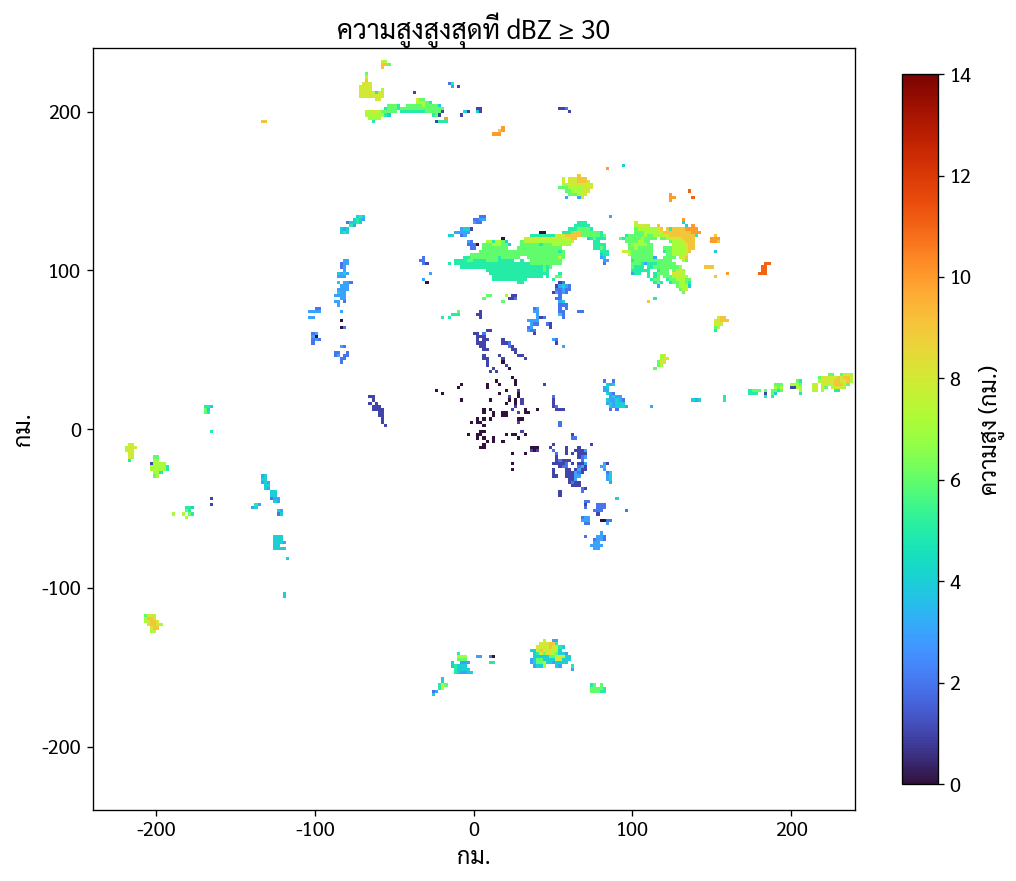

In [ ]:
LEV = 30.0
h30 = np.where(vol >= LEV, zg, np.nan)
h30 = np.nanmax(h30, axis=0)
fig, ax = plt.subplots(figsize=(9, 8))
pm = ax.imshow(h30, origin='lower', extent=[-240,240,-240,240], cmap='turbo', vmin=0, vmax=14)
ax.set_title(f'ความสูงสูงสุดที่ dBZ ≥ {LEV:.0f}'); ax.set_xlabel('กม.'); ax.set_ylabel('กม.'); ax.set_aspect('equal')
plt.colorbar(pm, ax=ax, shrink=0.8, label='ความสูง (กม.)')
plt.tight_layout(); plt.show()

## A8 — โปรไฟล์แนวดิ่งเฉลี่ย (Vertical Profile of Reflectivity, VPR)

เฉลี่ย reflectivity ในแต่ละระดับความสูงทั่วพื้นที่ฝน — เห็นภาพรวมโครงสร้างแนวดิ่งของระบบ


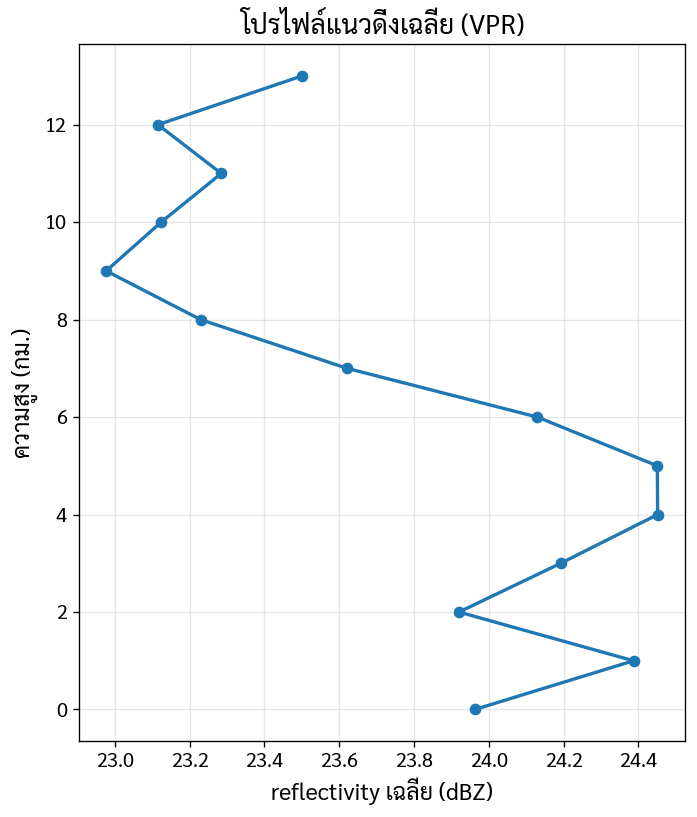

จุดที่ VPR โป่งขึ้นที่ ~4–5 กม. อาจเป็นสัญญาณ bright band (ระดับหลอมละลาย)


In [ ]:
with np.errstate(invalid='ignore'):
    vpr = np.array([np.nanmean(np.where(vol[k] > 0, vol[k], np.nan)) for k in range(NZ)])
fig, ax = plt.subplots(figsize=(6, 7))
ax.plot(vpr, zkm, marker='o', lw=2)
ax.set_xlabel('reflectivity เฉลี่ย (dBZ)'); ax.set_ylabel('ความสูง (กม.)')
ax.set_title('โปรไฟล์แนวดิ่งเฉลี่ย (VPR)'); ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(os.path.join(OUT, 'A8_vpr.png'), dpi=200, bbox_inches='tight')
plt.show()
print("จุดที่ VPR โป่งขึ้นที่ ~4–5 กม. อาจเป็นสัญญาณ bright band (ระดับหลอมละลาย)")

## A9 — พัด (fan) ของ cross-section หลายทิศ

ตัดหลายทิศจากแกนพายุ เพื่อดูโครงสร้างรอบด้าน


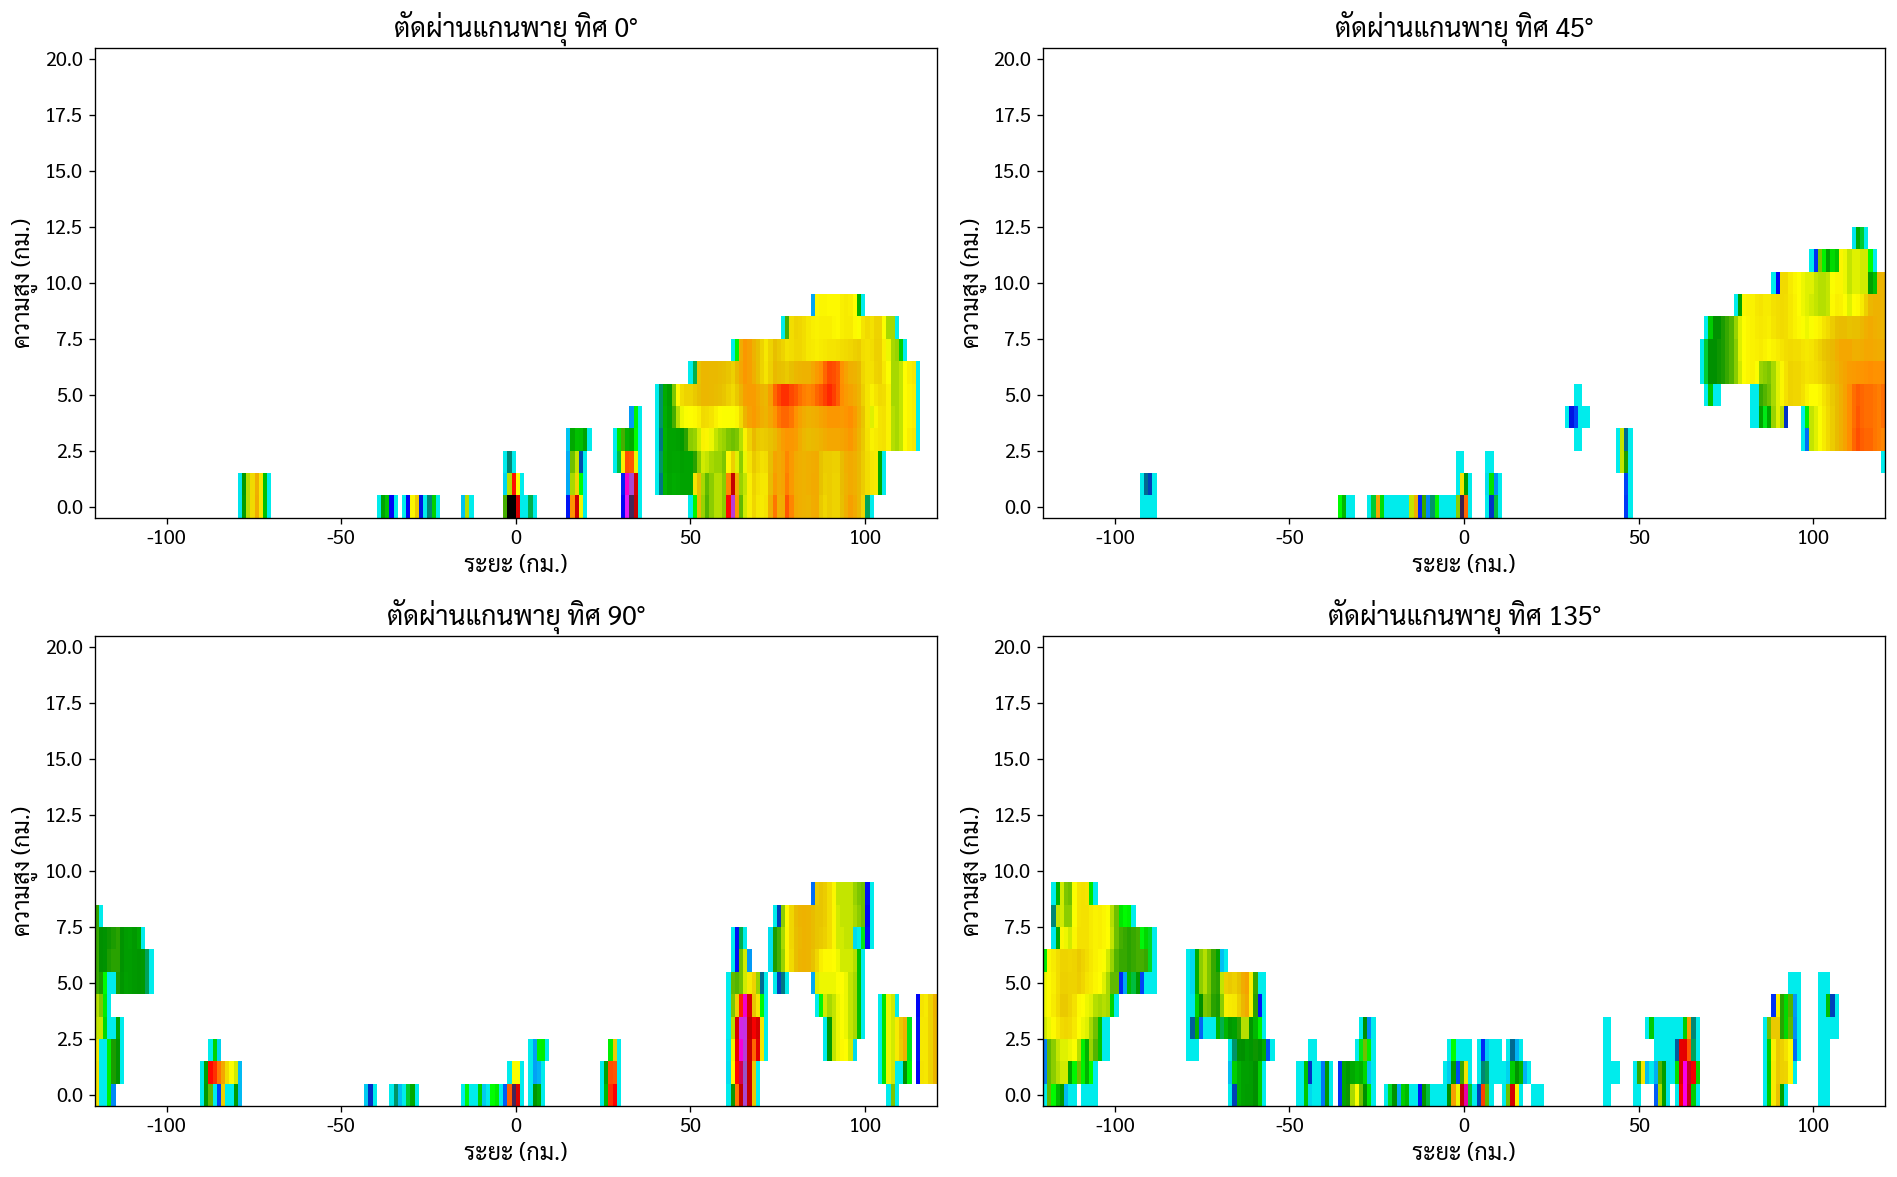

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, az in zip(axes.flat, [0, 45, 90, 135]):
    ang = np.radians(az); L = 120
    p0 = (xkm[ix]-L*np.sin(ang), ykm[iy]-L*np.cos(ang))
    p1 = (xkm[ix]+L*np.sin(ang), ykm[iy]+L*np.cos(ang))
    sec, dist = cross_line(vol, p0, p1)
    pm = ax.pcolormesh(dist-dist.mean(), zkm, np.ma.masked_invalid(sec), cmap='NWSRef',
                       vmin=-10, vmax=60, shading='auto')
    ax.set_title(f'ตัดผ่านแกนพายุ ทิศ {az}°'); ax.set_xlabel('ระยะ (กม.)'); ax.set_ylabel('ความสูง (กม.)')
plt.tight_layout()
fig.savefig(os.path.join(OUT, 'A9_fan_sections.png'), dpi=200, bbox_inches='tight')
plt.show()

**การแปลผล:** เทียบความกว้าง/ความสูงแกนพายุในแต่ละทิศ — พายุอาจเอียง (tilt) หรือมี overhang ในบางทิศ


## A10 — ดัชนีความรุนแรงแนวดิ่ง (คล้าย VIL)

รวมค่า reflectivity ในแนวดิ่ง (แปลงเป็นเชิงเส้นก่อนรวม) เป็นดัชนีความรุนแรง/ปริมาณน้ำในก้อนเมฆ ใช้ในการเตือนภัยลูกเห็บ/พายุรุนแรง


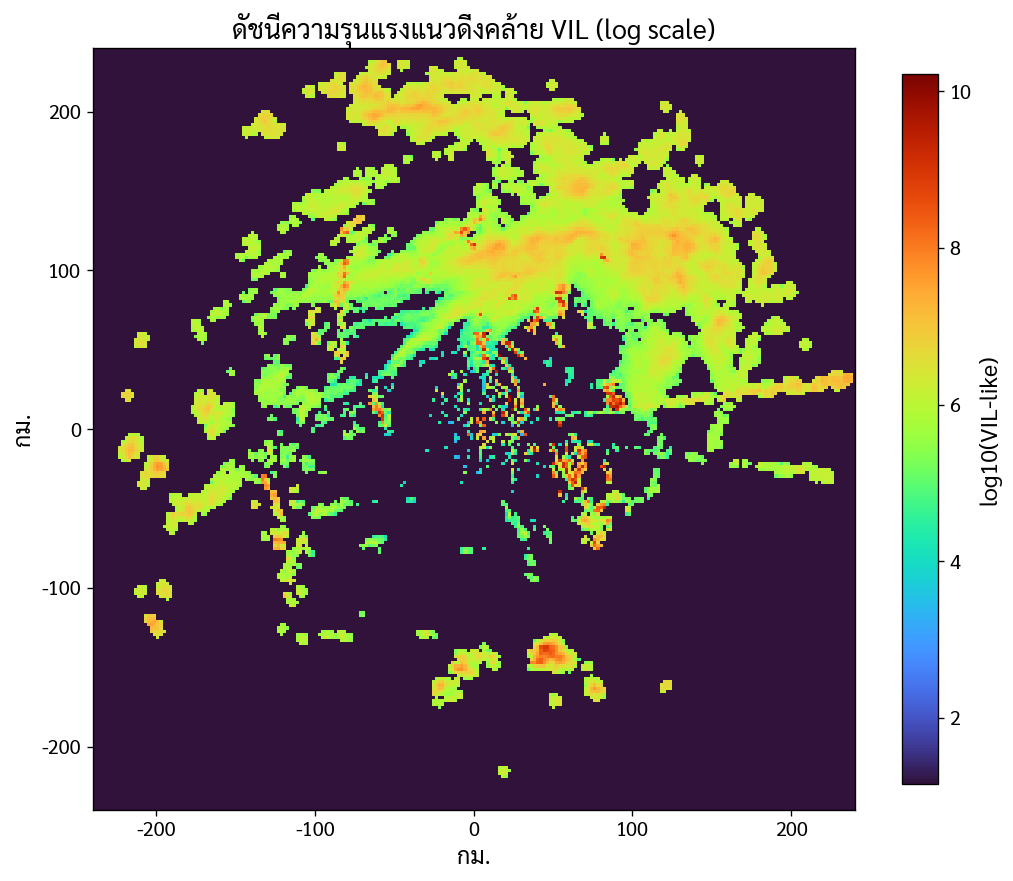

จุดที่ดัชนีสูง = แกนพายุที่มีน้ำ/ลูกเห็บมาก ควรจับตาเป็นพิเศษ


In [ ]:
dz = np.gradient(zkm) * 1000.0                 # ความหนาชั้น (m)
z_lin = 10.0 ** (np.nan_to_num(vol, nan=-32.0) / 10.0)
vil_like = np.nansum(z_lin * dz[:, None, None], axis=0)
vil_like[colmax < 0] = np.nan

fig, ax = plt.subplots(figsize=(9, 8))
pm = ax.imshow(np.log10(vil_like+1), origin='lower', extent=[-240,240,-240,240], cmap='turbo')
ax.set_title('ดัชนีความรุนแรงแนวดิ่งคล้าย VIL (log scale)')
ax.set_xlabel('กม.'); ax.set_ylabel('กม.'); ax.set_aspect('equal')
plt.colorbar(pm, ax=ax, shrink=0.8, label='log10(VIL-like)')
plt.tight_layout()
fig.savefig(os.path.join(OUT, 'A10_vil_like.png'), dpi=200, bbox_inches='tight')
plt.show()
print("จุดที่ดัชนีสูง = แกนพายุที่มีน้ำ/ลูกเห็บมาก ควรจับตาเป็นพิเศษ")

## 📝 แบบฝึกหัด

1. เปลี่ยน `TARGET_AZ` (A1) และเส้นตัด (A4) ให้ผ่านเซลล์ฝนต่าง ๆ — เซลล์ใดพัฒนาแนวดิ่งสูงสุด?
2. เปลี่ยนเกณฑ์ echo top (A6) เป็น 10 หรือ 30 dBZ แล้วเทียบแผนที่ความสูง
3. เลือกจุดสตราติฟอร์มที่ชัดเจน (A5) แล้วดูว่ามี bright band ที่ระดับใด (โยงกับระดับ 0°C จาก sounding บท 07)
4. (ต่อยอด) ทำ cross-section ของ **velocity** (แทน reflectivity) เพื่อดูโครงสร้างลมแนวดิ่ง


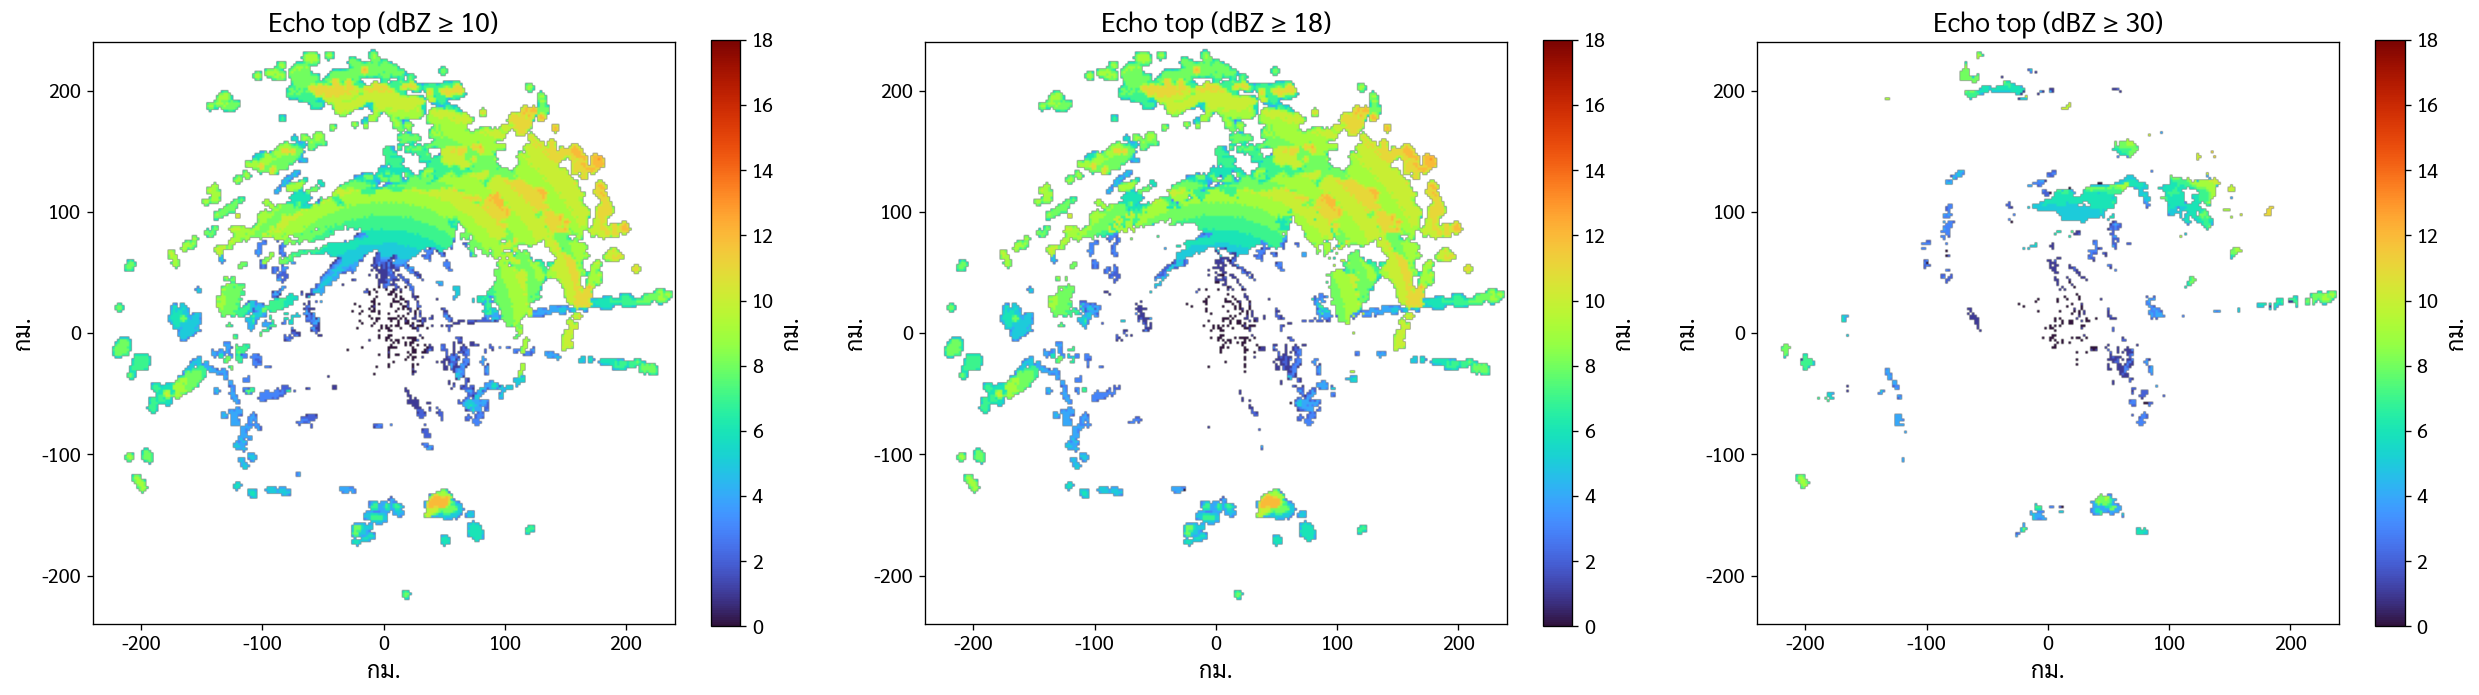

In [ ]:
# แบบฝึกหัดข้อ 2 (โครงเริ่มต้น): echo top หลายเกณฑ์
fig, axes = plt.subplots(1, 3, figsize=(21, 6.5))
for ax, th in zip(axes, [10., 18., 30.]):
    et = np.nanmax(np.where(vol >= th, zg, np.nan), axis=0)
    pm = ax.imshow(et, origin='lower', extent=[-240,240,-240,240], cmap='turbo', vmin=0, vmax=18)
    ax.set_title(f'Echo top (dBZ ≥ {th:.0f})'); ax.set_xlabel('กม.'); ax.set_ylabel('กม.'); ax.set_aspect('equal')
    plt.colorbar(pm, ax=ax, shrink=0.8, label='กม.')
plt.tight_layout(); plt.show()
# TODO (นิสิต): ทำข้อ 1, 3, 4 ต่อ

---
## 🎯 สรุป

- **RHI/pseudo-RHI** และ **cross-section** เปิดมุมมองแนวดิ่งที่ PPI/CAPPI ให้ไม่ได้
- โครงสร้างแนวดิ่งแยก **พาความร้อน vs สตราติฟอร์ม** และเผยความสูง/ความรุนแรงของพายุ
- ผลิตภัณฑ์เชิงพื้นที่ (echo top, ความสูง dBZ, VPR, ดัชนีคล้าย VIL) สรุปข้อมูลแนวดิ่งให้ใช้เตือนภัยได้
- เชื่อมโยงกับ **ระดับหลอมละลาย (0°C)** ในบท 07 และการจำแนกไฮโดรมีทีเออร์

🎓 **เมื่อรวมกับบท 03 (QC) และ 04 (gridding) นิสิตจะเข้าใจการประมวลผลเรดาร์ครบทั้งแนวราบและแนวดิ่ง**
